In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
uber = pd.read_csv('/Users/atienojacinta/PYDATA /Data_Storytelling/ncr_ride_bookings.csv')

In [6]:
uber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [7]:
uber.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [8]:
pd.options.display.max_columns = 100

In [61]:
uber.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Hour,Period,Pickup Code,Drop Code,Rated_Driver,Ride Status
0,2024-03-23,2025-10-04 12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,Afternoon,116,68,False,Complete
1,2024-11-29,2025-10-04 18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,18,Evening,149,47,False,Incomplete
2,2024-08-23,2025-10-04 08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,8,Morning,80,90,True,Complete
3,2024-10-21,2025-10-04 17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,17,Afternoon,21,60,True,Complete
4,2024-09-16,2025-10-04 22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,22,Evening,39,79,True,Complete


In [14]:
uber[['Date','Time']].dtypes

Date    object
Time    object
dtype: object

In [15]:
uber['Date'] = pd.to_datetime(uber['Date'])

In [17]:
uber['Time'] = pd.to_datetime(uber['Time'])

/var/folders/b7/64294z_j16d0t1nszkgct6_c0000gn/T/ipykernel_23942/1990077311.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  uber['Time'] = pd.to_datetime(uber['Time'])


In [21]:
uber[['Date','Time']].dtypes

Date    datetime64[ns]
Time    datetime64[ns]
dtype: object

In [ ]:
# extracting the hour
uber['Hour'] = uber['Time'].dt.hour

In [25]:
bins = [0,6,12,18,24]
labels = ['Night', 'Morning', 'Afternoon', 'Evening']

In [29]:
# Getting the time of day from hour-Night, Morning, Afternoon, Evening
uber['Period'] = pd.cut(uber['Hour'], bins=bins, labels=labels, right=False)

In [102]:
# Getting the day of week 

uber['Day'] = uber['Date'].dt.day_name()

In [107]:
uber.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Hour,Period,Pickup Code,Drop Code,Rated_Driver,Ride Status,Day,Day Type
0,2024-03-23,2025-10-04 12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,Afternoon,116,68,False,Complete,Saturday,Weekend
1,2024-11-29,2025-10-04 18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,18,Evening,149,47,False,Incomplete,Friday,Weekday
2,2024-08-23,2025-10-04 08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,8,Morning,80,90,True,Complete,Friday,Weekday
3,2024-10-21,2025-10-04 17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,17,Afternoon,21,60,True,Complete,Monday,Weekday
4,2024-09-16,2025-10-04 22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,22,Evening,39,79,True,Complete,Monday,Weekday


In [104]:
# Getting the day type

uber['Day Type'] = uber['Day'].apply(lambda x: 'Weekend' if x in ['Saturday','Sunday'] else 'Weekday')

In [33]:
uber['Pickup Location'].value_counts()

Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
                   ... 
Mandi House         800
Noida Sector 18     799
Laxmi Nagar         797
Ashok Vihar         796
Ghitorni Village    790
Name: count, Length: 176, dtype: int64

In [34]:
uber['Drop Location'].value_counts()

Drop Location
Ashram              936
Basai Dhankot       917
Lok Kalyan Marg     916
Narsinghpur         913
Cyber Hub           912
                   ... 
MG Road             799
Bhiwadi             792
Shivaji Park        786
Anand Vihar ISBT    784
Huda City Centre    774
Name: count, Length: 176, dtype: int64

In [38]:
uber[['Drop Location','Pickup Location']].head()

,Drop Location,Pickup Location
0,Jhilmil,Palam Vihar
1,Gurgaon Sector 56,Shastri Nagar
2,Malviya Nagar,Khandsa
3,Inderlok,Central Secretariat
4,Khan Market,Ghitorni Village


In [40]:
uber['Drop Location'].nunique()

176

In [41]:
uber['Pickup Location'].nunique()

176

In [111]:
rides_by_day_type = uber['Day Type'].value_counts().sort_index()

In [112]:
rides_by_day_type

Day Type
Weekday    107060
Weekend     42940
Name: count, dtype: int64

In [132]:
rides_by_period = uber['Period'].value_counts().sort_index()

In [131]:
rides_by_period

Period
Night         9562
Morning      42672
Afternoon    48386
Evening      49380
Name: count, dtype: int64

In [115]:
ride_counts = uber['Booking Status'].value_counts()


In [116]:
ride_counts

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

In [124]:
ride_percent = 100 * ride_counts / ride_counts.sum()

In [127]:
ride_percent

Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: count, dtype: float64

/var/folders/b7/64294z_j16d0t1nszkgct6_c0000gn/T/ipykernel_23942/2488923854.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ride_percent.index, y=ride_percent.values, palette='Set2')


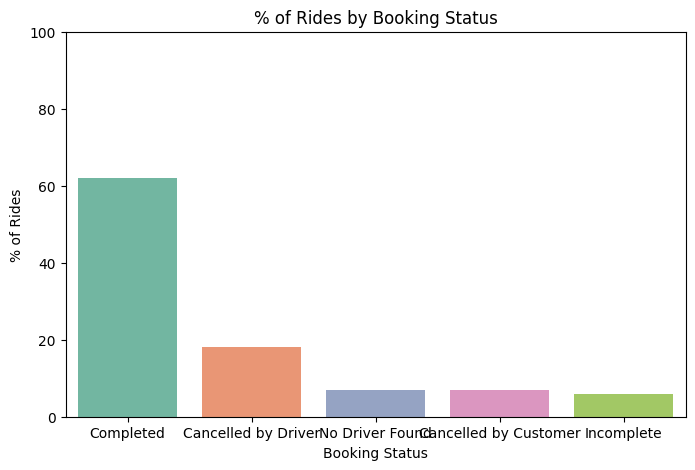

In [129]:
plt.figure(figsize=(8,5))
sns.barplot(x=ride_percent.index, y=ride_percent.values, palette='Set2')
plt.title('% of Rides by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('% of Rides')
plt.ylim(0, 100)
plt.show()

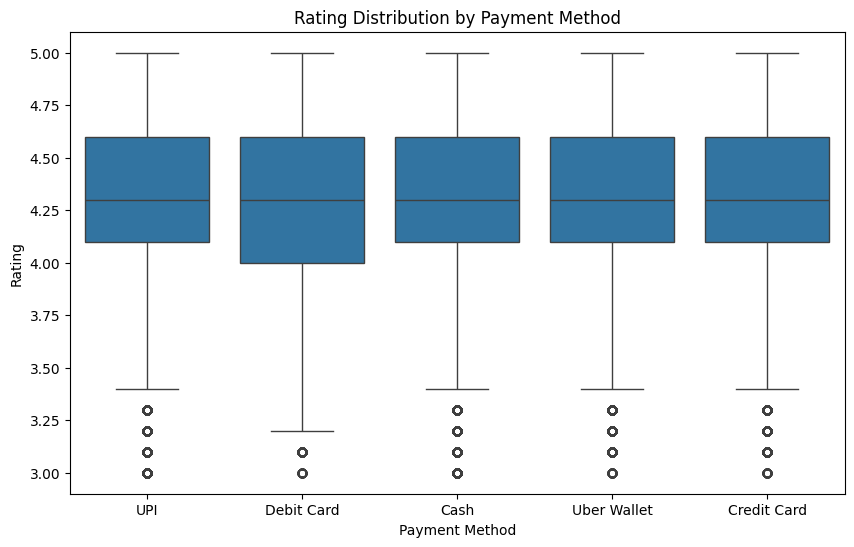

In [ ]:
# payment method vs driver ratings

plt.figure(figsize=(10,6))
sns.boxplot(data=uber, x='Payment Method', y='Driver Ratings')
plt.title('Rating Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Rating')
plt.show()

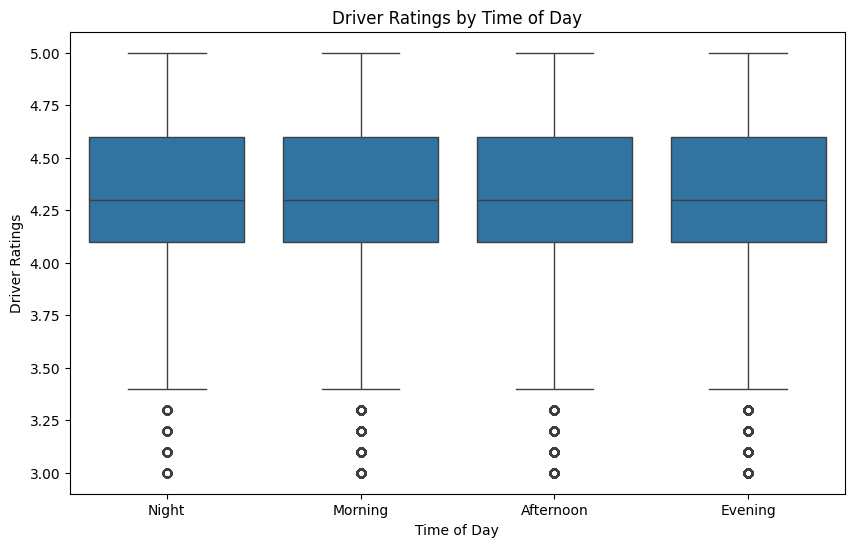

In [108]:
# Time of Day vs driver ratings

plt.figure(figsize=(10,6))
sns.boxplot(data=uber, x='Period', y='Driver Ratings')
plt.title('Driver Ratings by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Driver Ratings')
plt.show()

In [ ]:
# Day of week vs driver ratings

plt.figure(figsize=(10,6))
sns.boxplot(data=uber, x='Period', y='Driver Ratings')
plt.title('Driver Ratings by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Driver Ratings')
plt.show()

In [49]:
uber['Rated_Driver'] = uber['Driver Ratings'].notna()

In [50]:
rating_counts = uber.groupby('Payment Method')['Rated_Driver'].value_counts().unstack().fillna(0)
print(rating_counts)

Rated_Driver    False  True 
Payment Method              
Cash             2253  23114
Credit Card       889   9320
Debit Card        713   7526
UPI              4075  41834
Uber Wallet      1070  11206


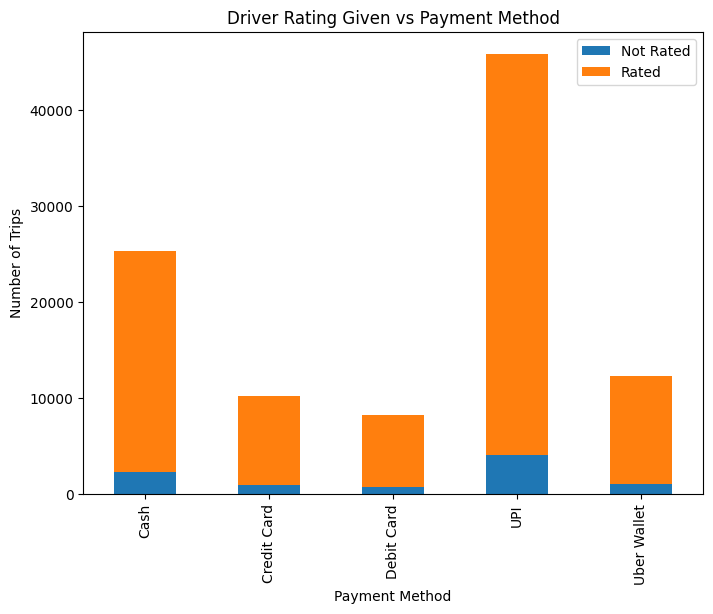

In [52]:
rating_counts.plot(kind='bar', stacked=True, figsize=(8,6))
plt.title('Driver Rating Given vs Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Trips')
plt.legend(['Not Rated','Rated'])
plt.show()

In [51]:
uber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 26 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  datetime64[ns]
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by C

In [56]:
uber['Incomplete Rides'].unique()

array([nan,  1.])

In [57]:
uber['Ride Status'] = uber['Incomplete Rides'].apply(lambda x: 'Incomplete' if x == 1 else 'Complete')

In [58]:
uber['Ride Status'].value_counts()

Ride Status
Complete      141000
Incomplete      9000
Name: count, dtype: int64

/var/folders/b7/64294z_j16d0t1nszkgct6_c0000gn/T/ipykernel_23942/1730227036.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Payment Method')


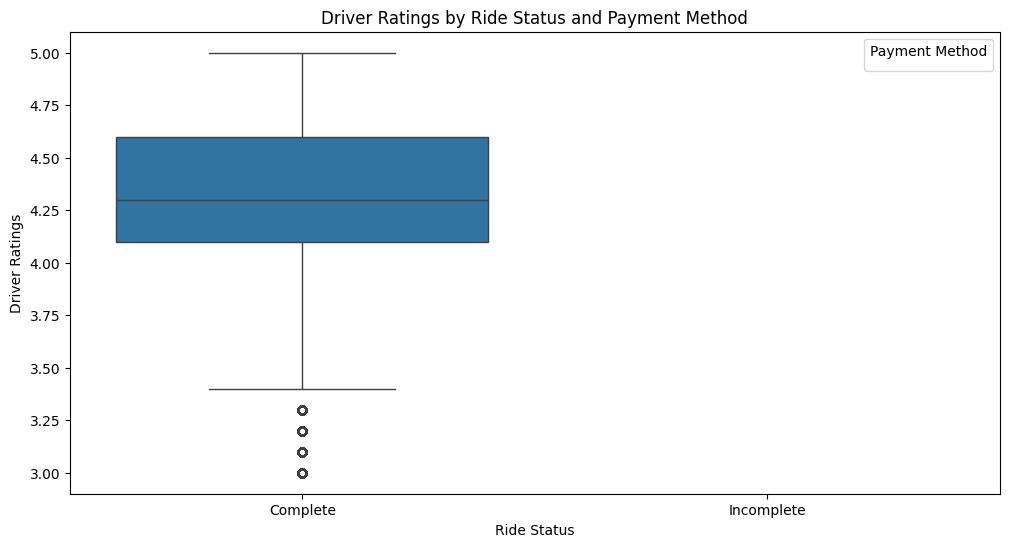

In [60]:
plt.figure(figsize=(12,6))
sns.boxplot(data=uber, x='Ride Status', y='Driver Ratings')
plt.title('Driver Ratings by Ride Status and Payment Method')
plt.xlabel('Ride Status')
plt.ylabel('Driver Ratings')
plt.legend(title='Payment Method')
plt.show()

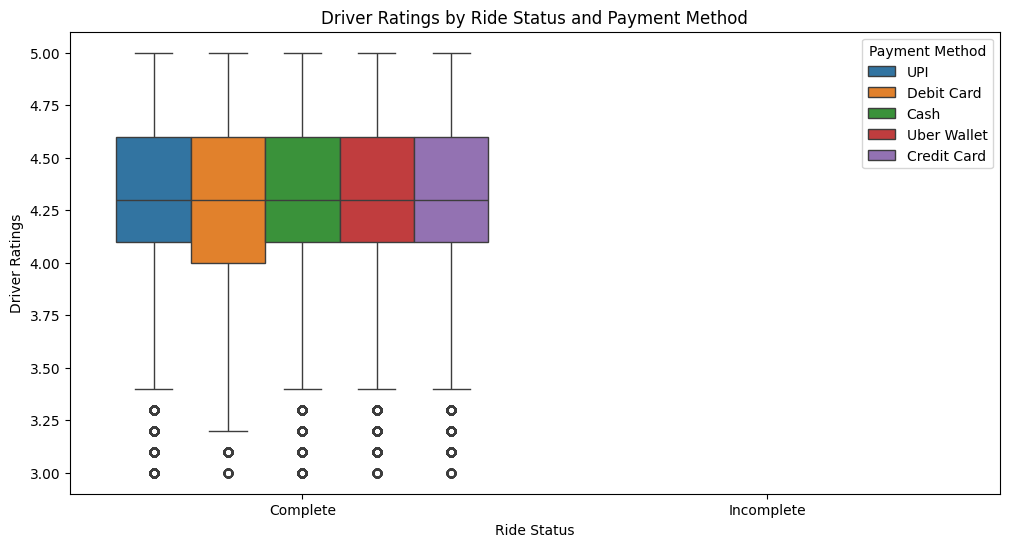

In [59]:
plt.figure(figsize=(12,6))
sns.boxplot(data=uber, x='Ride Status', y='Driver Ratings', hue='Payment Method')
plt.title('Driver Ratings by Ride Status and Payment Method')
plt.xlabel('Ride Status')
plt.ylabel('Driver Ratings')
plt.legend(title='Payment Method')
plt.show()

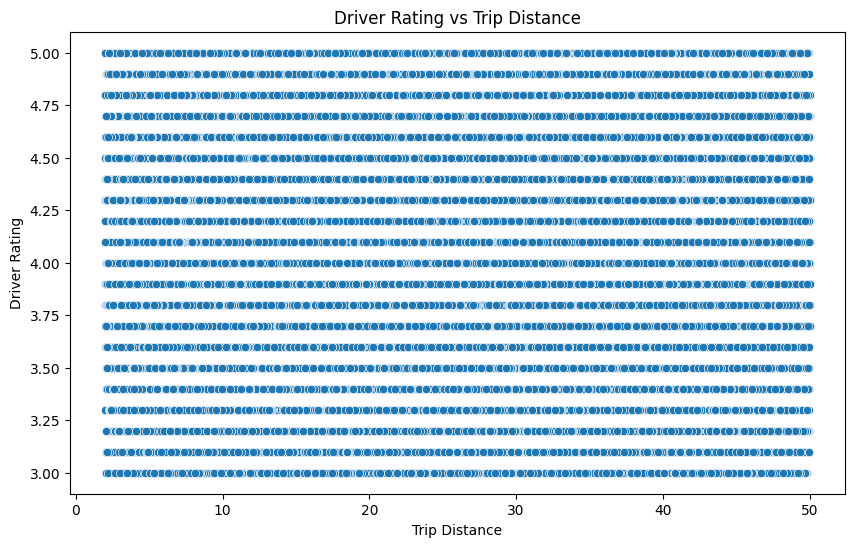

In [64]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=uber, x='Ride Distance', y='Driver Ratings')
plt.title('Driver Rating vs Trip Distance')
plt.xlabel('Trip Distance')
plt.ylabel('Driver Rating')
plt.show()

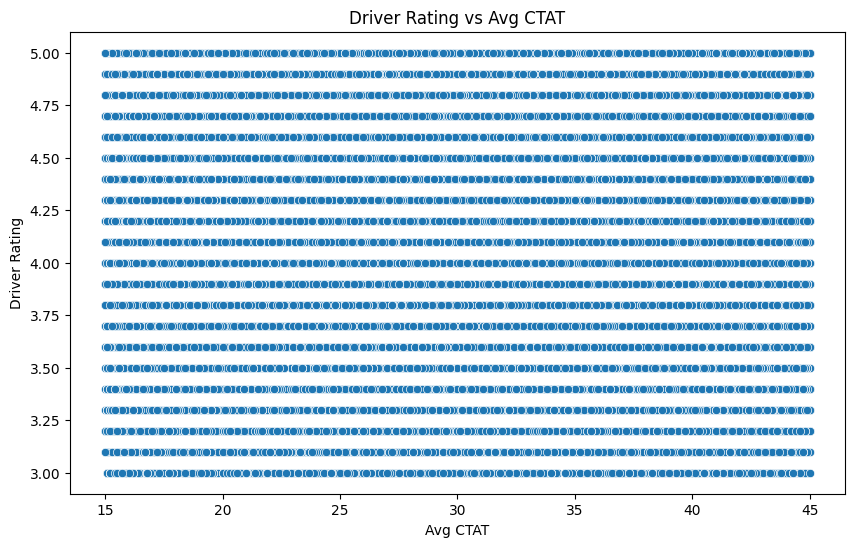

In [67]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=uber, x='Avg CTAT', y='Driver Ratings')
plt.title('Driver Rating vs Avg CTAT')
plt.xlabel('Avg CTAT')
plt.ylabel('Driver Rating')
plt.show()

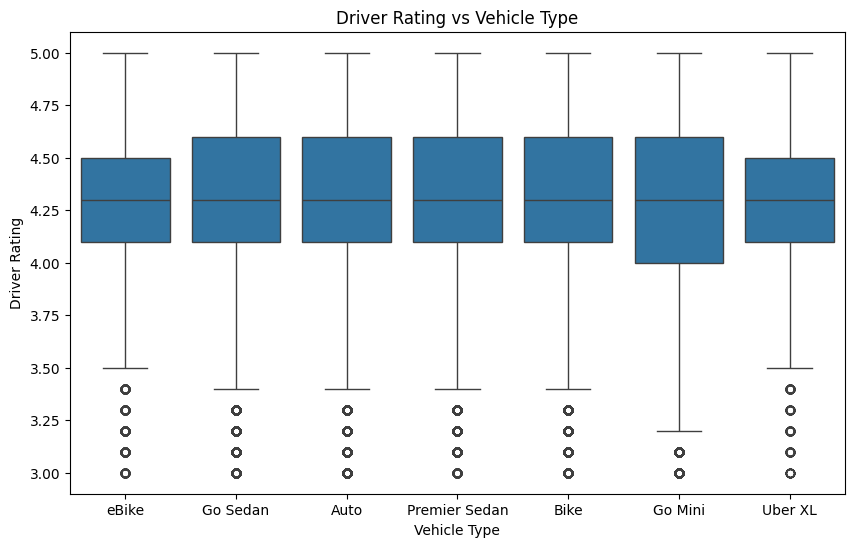

In [69]:
plt.figure(figsize=(10,6))
sns.boxplot(data=uber, x='Vehicle Type', y='Driver Ratings')
plt.title('Driver Rating vs Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Driver Rating')
plt.show()

In [82]:
ratings = uber.melt(id_vars=['Vehicle Type'],value_vars=['Driver Ratings', 'Customer Rating'],var_name='Rating Type',value_name='Rating')

/var/folders/b7/64294z_j16d0t1nszkgct6_c0000gn/T/ipykernel_23942/1406614587.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=ratings, x='Vehicle Type', y='Rating', hue='Rating Type', ci=None)


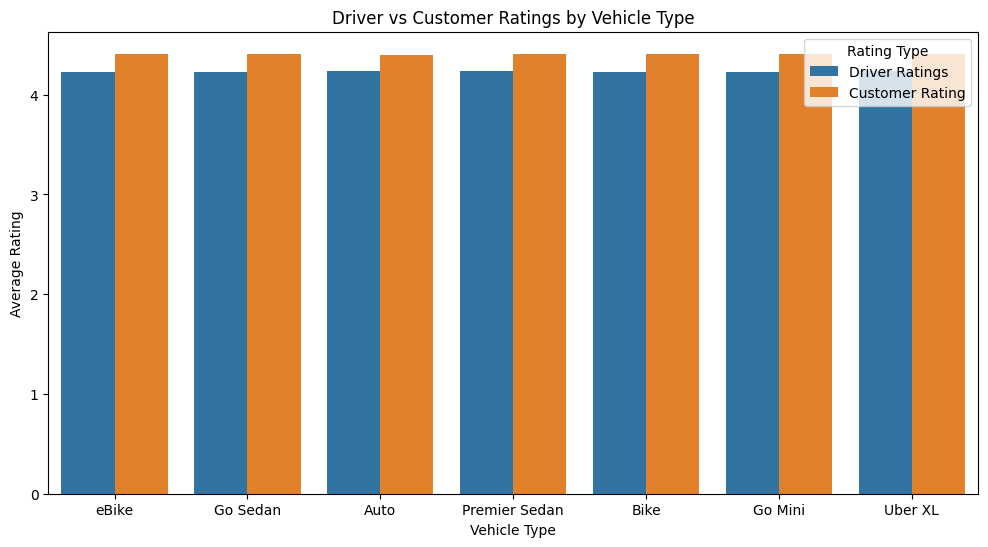

In [87]:
plt.figure(figsize=(12,6))
sns.barplot(data=ratings, x='Vehicle Type', y='Rating', hue='Rating Type', ci=None)
plt.title('Driver vs Customer Ratings by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Rating')
plt.show()

In [91]:
low_driver_ratings = uber[uber['Driver Ratings'] < 4]


In [96]:
low_driver_counts = low_driver_ratings.groupby('Customer ID').size().reset_index(name='Low Driver Ratings Count')

In [97]:
low_driver_counts

,Customer ID,Low Driver Ratings Count
0,"""CID1000448""",1
1,"""CID1000710""",1
2,"""CID1000804""",1
3,"""CID1000836""",1
4,"""CID1000862""",1
...,...,...
21002,"""CID9998720""",1
21003,"""CID9998815""",1
21004,"""CID9998923""",1
21005,"""CID9999282""",1


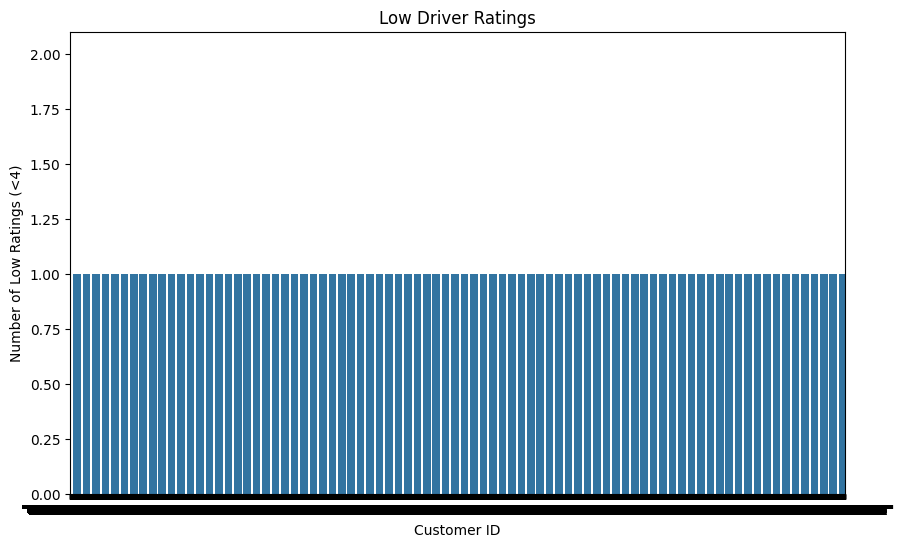

In [99]:
plt.figure(figsize=(10,6))
sns.barplot(data=low_driver_counts, x='Customer ID', y='Low Driver Ratings Count')
plt.title('Low Driver Ratings')
plt.xlabel('Customer ID')
plt.ylabel('Number of Low Ratings (<4)')
plt.show()

In [43]:
uber.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method', 'Hour', 'Period',
       'Pickup Code', 'Drop Code'],
      dtype='object')